In [ ]:
#imported librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
# Loaded data
df = pd.read_csv("/content/fraud_0.1origbase.csv")

In [ ]:
df.shape

(636262, 11)

In [ ]:
df.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


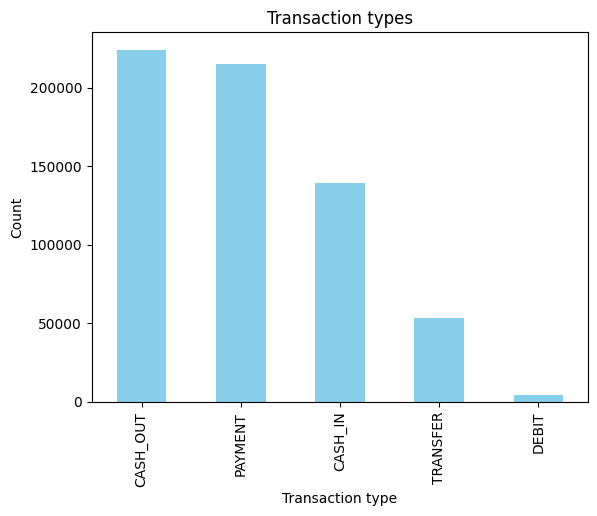

In [ ]:
# EDA
df["type"].value_counts().plot(kind="bar", title="Transaction types", color="skyblue")
plt.xlabel("Transaction type")
plt.ylabel("Count")
plt.show()

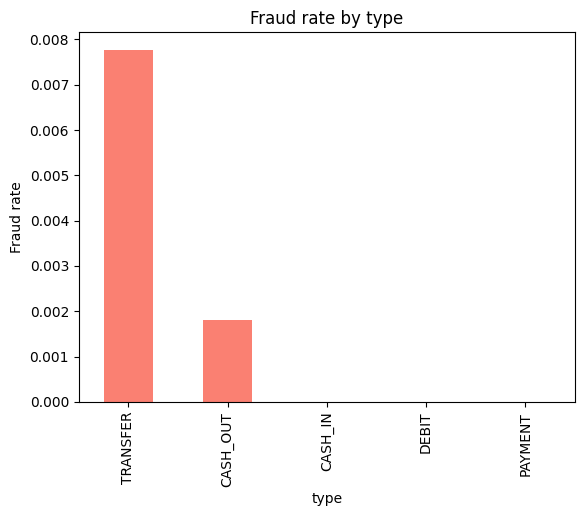

In [ ]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud rate by type", color="salmon")
plt.ylabel("Fraud rate")
plt.show()

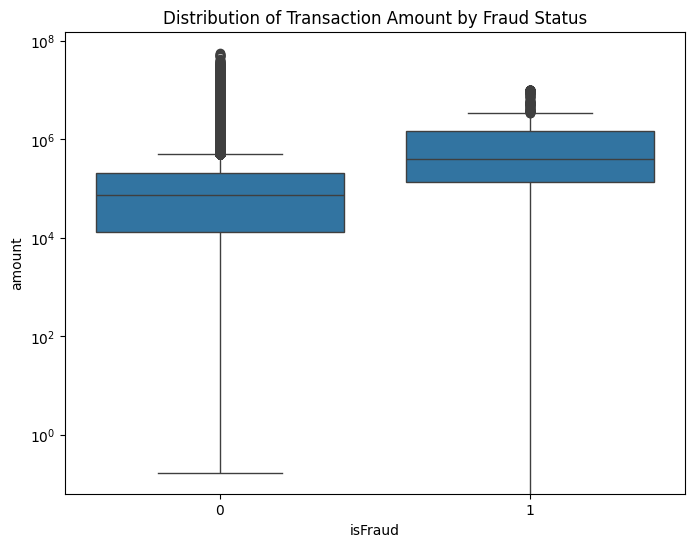

In [ ]:
# Boxplot for Amount (Checking for Outliers in Fraud vs Legitimate)
plt.figure(figsize=(8, 6))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log') # Log scale helps visualize large discrepancies
plt.title("Distribution of Transaction Amount by Fraud Status")
plt.show()

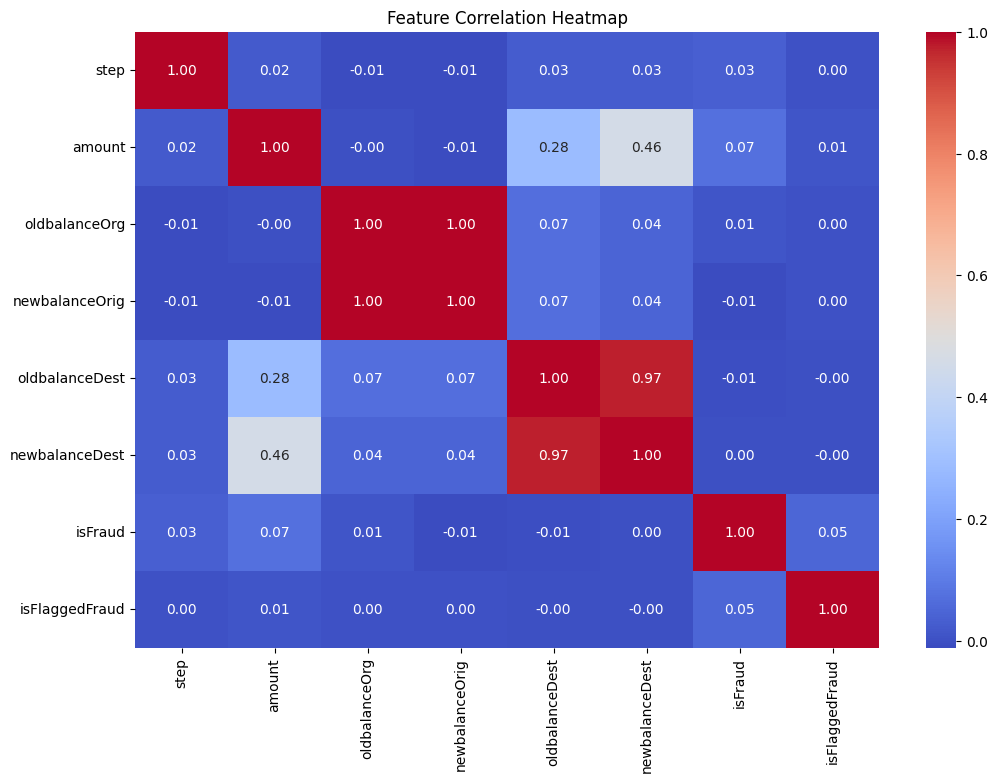

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# FILTER TRANSACTION TYPES
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

In [ ]:
# FEATURE ENGINEERING
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

In [ ]:
# DATA CLEANING
df.drop(columns=['nameOrig', 'nameDest', 'step',"isFlaggedFraud"], inplace=True, errors='ignore')

In [ ]:
# ENCODING
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [ ]:
df.dtypes

,0
amount,float64
oldbalanceOrg,float64
newbalanceOrig,float64
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64
errorBalanceOrig,float64
errorBalanceDest,float64
type_TRANSFER,bool


In [ ]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
df["isFraud"].value_counts()

,count
isFraud,
0,276689
1,821


In [ ]:
# HANDLE IMBALANCE -->using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.preprocessing import RobustScaler

# SCALING
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_res)  # fit ONLY on train
X_test_scaled = scaler.transform(X_test)             # transform test


In [ ]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        eval_metric='logloss',
        random_state=42
    )}

In [ ]:
# TRAIN & EVALUATE
# =======================
for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    y_pred = model.predict(X_test_scaled)

    print("\n" + "="*40)
    print(f"MODEL: {name}")
    print("="*40)
    print(classification_report(y_test, y_pred))


MODEL: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55338
           1       0.99      0.99      0.99       164

    accuracy                           1.00     55502
   macro avg       0.99      1.00      1.00     55502
weighted avg       1.00      1.00      1.00     55502


MODEL: KNN
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     55338
           1       0.33      0.95      0.49       164

    accuracy                           0.99     55502
   macro avg       0.67      0.97      0.74     55502
weighted avg       1.00      0.99      1.00     55502


MODEL: Naive Bayes
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     55338
           1       0.01      0.06      0.01       164

    accuracy                           0.97     55502
   macro avg       0.50      0.52      0.50     55502
weighted avg       0

In [ ]:
# XGBoost Model
final_model = XGBClassifier(
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    random_state=42,
    eval_metric='logloss'
)

# Train model
final_model.fit(X_train_scaled, y_train_res)

# Evaluate
y_pred = final_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55338
           1       0.88      0.99      0.93       164

    accuracy                           1.00     55502
   macro avg       0.94      0.99      0.97     55502
weighted avg       1.00      1.00      1.00     55502



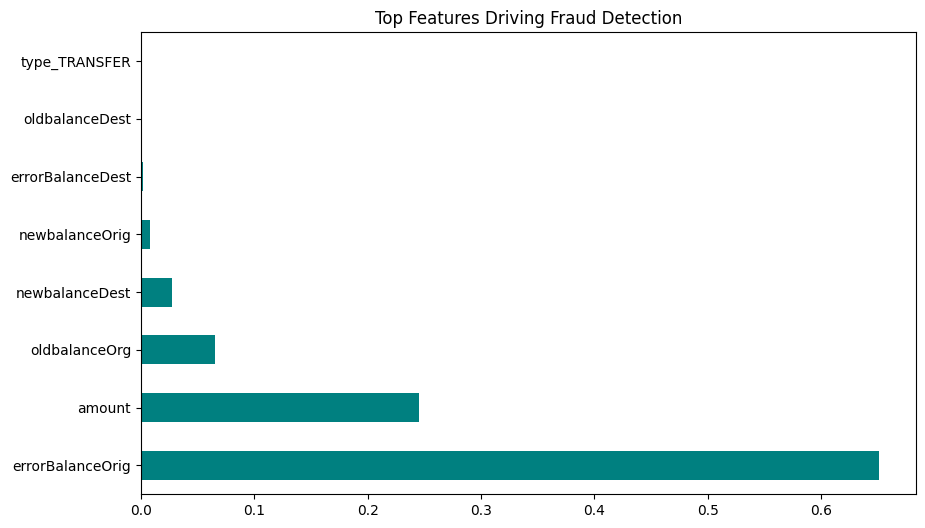

In [ ]:
# Feature Importance Plot
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(final_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top Features Driving Fraud Detection")
plt.show()

In [ ]:
# SAVE MODEL & OBJECTS
pickle.dump(final_model, open("model1.pkl", "wb"))
pickle.dump(scaler, open("scaler1.pkl", "wb"))
pickle.dump(X.columns, open("features1.pkl", "wb"))

print("✅ Success: model1.pkl, scaler1.pkl, and features1.pkl saved.")

✅ Success: model1.pkl, scaler1.pkl, and features1.pkl saved.
